In [2]:
#Lets generate sample function to generate videoids and video attributes
import random
import string
import pandas as pd
from datetime import datetime
import numpy as np
def randomStringDigits(stringLength=6):
    """Generate a random string of letters and digits """
    lettersAndDigits = string.ascii_letters + string.digits
    return ''.join(random.choice(lettersAndDigits).join(random.choice(lettersAndDigits)) for i in range(stringLength))
print ("Generating a Random String including letters and digits")
print ("First Random String is  ", randomStringDigits(8))

Generating a Random String including letters and digits
First Random String is   FqKHzd8W


In [14]:
video_count=pd.DataFrame()

In [30]:
videoid=pd.DataFrame(randomStringDigits(8) for _ in range(50000))

In [32]:
noofviews=pd.DataFrame(np.random.randint(20,48,size=50000))

In [37]:
import random
import time
from random import randrange
import datetime 
import time
start_timestamp1 = time.mktime(time.strptime('01/06/2017  12:33:00','%d/%m/%Y %H:%M:%S'))
end_timestamp1 = time.mktime(time.strptime('01/03/2020 14:33:00','%d/%m/%Y %H:%M:%S'))
date=pd.DataFrame([time.strftime("%d/%m/%y %H:%M:%S",time.localtime(randrange(start_timestamp1,end_timestamp1))) for _ in range(50000)])
#Generate sample transactionid

In [42]:
video_count=pd.concat([date,videoid,noofviews],axis=1)

In [ ]:
ideo_id    41775 non-null int64
count       41775 non-null int64
date        41775 non-null object

In [43]:
video_count.columns=['date','video_id','count']

In [45]:
#Lets analyse the video count data. 
video_count.describe()

,count
count,50000.000000
mean,33.533700
std,8.078892
min,20.000000
25%,27.000000
50%,34.000000
75%,41.000000
max,47.000000


In [46]:
video_count.drop_duplicates()

,date,video_id,count
0,08/10/18 21:51:54,9Km6Ovdn,27
1,11/11/19 01:55:32,rEWGN4gR,37
2,14/11/19 10:09:01,vtZz8Xvc,42
3,26/07/18 16:15:52,kDjmyKgC,27
4,29/04/18 15:14:31,Y7wrY9Bb,41
5,22/11/18 03:23:06,f120oG5q,45
6,16/07/19 22:37:32,F0F4rKl6,39
7,25/08/19 10:27:27,7DjacOGt,31
8,06/06/18 16:31:21,mnS9juSw,42
9,29/07/17 20:47:53,Zx3MSF77,22


In [47]:
#check the datatypes of the dataframe
video_count.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
date        50000 non-null object
video_id    50000 non-null object
count       50000 non-null int64
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [49]:
# Need to convert the date column to a datetime object
video_count['date']=pd.to_datetime(video_count['date'])

In [50]:
#check for any missing values
video_count.isnull().sum()
#No missing values in the data

date        0
video_id    0
count       0
dtype: int64

In [66]:

videoquality=['180p','720p']
video_quality=pd.DataFrame([np.random.choice(videoquality) for _ in range(50000)])


In [67]:
videolanguage=['En','Cn']
video_language=pd.DataFrame([np.random.choice(videolanguage) for _ in range(50000)])

In [68]:
videouploaddate=pd.DataFrame([time.strftime("%d/%m/%y %H:%M:%S",time.localtime(randrange(start_timestamp1,end_timestamp1))) for _ in range(50000)])
#Generate sample transactionid

In [69]:
videolength=pd.DataFrame(np.random.randint(120,180,size=50000))

In [73]:
video_features=pd.concat([video_quality,video_language,videouploaddate,videolength],axis=1)

In [75]:
video_features=pd.concat([video_features,videoid],axis=1)

In [77]:
video_features.columns=['video_quality','video_language','video_upload_date', 'video_length','video_id']

In [78]:
#merge videocount and video features
mergeddata=pd.merge(video_count,video_features,on='video_id')

In [79]:
mergeddata.columns

Index(['date', 'video_id', 'count', 'video_quality', 'video_language',
       'video_upload_date', 'video_length'],
      dtype='object')

In [80]:
mergeddata

,date,video_id,count,video_quality,video_language,video_upload_date,video_length
0,2018-08-10 21:51:54,9Km6Ovdn,27,720p,Cn,22/03/19 13:31:13,150
1,2019-11-11 01:55:32,rEWGN4gR,37,720p,En,28/02/18 13:31:54,134
2,2019-11-14 10:09:01,vtZz8Xvc,42,720p,En,17/11/19 00:17:50,169
3,2018-07-26 16:15:52,kDjmyKgC,27,180p,Cn,15/04/18 04:55:55,170
4,2018-04-29 15:14:31,Y7wrY9Bb,41,180p,En,08/11/19 01:49:57,135
5,2018-11-22 03:23:06,f120oG5q,45,720p,En,09/05/18 02:57:17,170
6,2019-07-16 22:37:32,F0F4rKl6,39,180p,Cn,06/11/19 23:37:10,124
7,2019-08-25 10:27:27,7DjacOGt,31,720p,Cn,21/01/19 08:02:14,147
8,2018-06-06 16:31:21,mnS9juSw,42,720p,Cn,17/08/19 19:27:33,141
9,2017-07-29 20:47:53,Zx3MSF77,22,180p,Cn,09/09/17 06:34:38,133


In [81]:
#calculate the mininum number of counts  We will ignore counts which are less than 10 percentile
m=mergeddata['count'].quantile(0.9)


In [82]:
m

45.0

In [83]:
# so as a first filter,We will ignore counts which are less than 1 percentile,thereby we will defibe the hot videos and stable videos are the ones whoch have counts greater than m and views greater than v.So lets isolate the videos whoch are neither hot nor stable
othervideos=mergeddata[(mergeddata['count']<m)]

In [84]:
#For our analysis of hot videos and stable videos we will use only those whose counts are greater than 1 percentile
mergeddata=mergeddata[(mergeddata['count']>m)]


In [85]:
mergeddata

,date,video_id,count,video_quality,video_language,video_upload_date,video_length
10,2017-08-25 21:13:20,Pjx70rWO,46,720p,Cn,04/08/17 18:44:11,134
28,2019-11-28 13:31:58,bjjdumGa,47,180p,En,06/01/20 05:21:32,128
30,2019-12-03 10:04:36,WnIg4Pyd,47,180p,En,13/11/17 10:16:44,137
31,2017-10-10 13:50:04,vNFPN68O,46,720p,En,28/02/19 08:27:59,129
43,2019-01-02 19:10:30,KC23I8aw,47,180p,Cn,15/02/19 01:16:13,127
47,2019-12-17 00:24:23,XoMeUO4x,47,720p,En,03/07/18 17:14:01,146
71,2019-11-22 01:17:03,Ye0Oo4aV,46,180p,En,06/04/19 11:47:04,166
84,2017-12-14 14:04:03,byY6dpv3,47,720p,Cn,07/11/17 16:00:32,176
86,2018-08-23 07:22:08,8zXdrm2M,46,720p,En,28/01/20 17:37:33,170
99,2018-05-02 02:16:41,mFS5kMyB,46,720p,En,17/10/18 02:19:02,168


#We Will need some metrics to do our classification and recommendations

In [86]:
#Get the total views for each video
import numpy as np
views=mergeddata.groupby("video_id")["count"].sum().reset_index()


In [87]:
views

,video_id,count
0,02kmr3Fd,47
1,03uMQmQa,47
2,05GVcxyp,46
3,05L7QuV7,46
4,08BSXJyv,47
5,09eKL6EG,46
6,09ionvMq,47
7,0ARPeGfk,46
8,0ApVhjGc,46
9,0AufqUmA,46


In [88]:
#Get the average length for each video
import numpy as np
length=mergeddata.groupby("video_id")["video_length"].median().reset_index()
length

,video_id,video_length
0,02kmr3Fd,152
1,03uMQmQa,161
2,05GVcxyp,139
3,05L7QuV7,140
4,08BSXJyv,142
5,09eKL6EG,121
6,09ionvMq,147
7,0ARPeGfk,136
8,0ApVhjGc,167
9,0AufqUmA,159


In [89]:
#Merging the metrics into a single dataset
summarydata=pd.merge(views,length,on='video_id')

In [90]:
summarydata.columns=['video_id','totalviews','averagelength']

In [91]:
video_count

,date,video_id,count
0,2018-08-10 21:51:54,9Km6Ovdn,27
1,2019-11-11 01:55:32,rEWGN4gR,37
2,2019-11-14 10:09:01,vtZz8Xvc,42
3,2018-07-26 16:15:52,kDjmyKgC,27
4,2018-04-29 15:14:31,Y7wrY9Bb,41
5,2018-11-22 03:23:06,f120oG5q,45
6,2019-07-16 22:37:32,F0F4rKl6,39
7,2019-08-25 10:27:27,7DjacOGt,31
8,2018-06-06 16:31:21,mnS9juSw,42
9,2017-07-29 20:47:53,Zx3MSF77,22


In [92]:
summarydata

,video_id,totalviews,averagelength
0,02kmr3Fd,47,152
1,03uMQmQa,47,161
2,05GVcxyp,46,139
3,05L7QuV7,46,140
4,08BSXJyv,47,142
5,09eKL6EG,46,121
6,09ionvMq,47,147
7,0ARPeGfk,46,136
8,0ApVhjGc,46,167
9,0AufqUmA,46,159


 We will define a metric called popularity index. We will define a video as popular if people tend to watch longer than others in other words popular video will be watched for a longer duration and  will have higher views .Combing the duration of video watched as well the count of people who watched the video, we will define popularity index as the Average length of the video multiplied by the total views it has got

popularity index of a given video=Average length of the video*total views for the video

In [93]:
def popindex(dataframe):
    return(dataframe['averagelength']*dataframe['totalviews'])

In [94]:
summarydata['popindex']=summarydata.apply(lambda x:popindex(x),axis=1)
summarydata['popindex']

0       7144
1       7567
2       6394
3       6440
4       6674
5       5566
6       6909
7       6256
8       7682
9       7314
10      6627
11      6204
12      6345
13      7314
14      7360
15      6251
16      6210
17      5704
18      7130
19      7003
20      7990
21      6157
22      7544
23      7130
24      6210
25      6439
26      7426
27      7544
28      6768
29      7614
        ... 
3647    8096
3648    7520
3649    5934
3650    7285
3651    6486
3652    6762
3653    6072
3654    6110
3655    6862
3656    7222
3657    6026
3658    6674
3659    5875
3660    8004
3661    7866
3662    7849
3663    5566
3664    7943
3665    5888
3666    6721
3667    6956
3668    7360
3669    5969
3670    6394
3671    6900
3672    7567
3673    5612
3674    6348
3675    7682
3676    7708
Name: popindex, Length: 3677, dtype: int64

In [95]:
#Normalizing the popularity index for easier interpretation
from statistics import mean 
from statistics import stdev
summarydata['popindex']=(summarydata['popindex']-mean(summarydata['popindex']))/(stdev(summarydata['popindex']))

we will use the popularity index to build a recommendation engine and also a classification

#Using the KPI popularity index as a means to classify our videos ,we will classify the video which have a popularity index greater than 1 to be "hot videos". This will account for the fact that videos which have high viewership count also high viewership length have generated high level of interest among users

In [96]:
summarydata['video_classify']=np.where(summarydata['popindex']>1,"Hot","Stable")

In [97]:
#Lets try to understand somemore features of the videos
finaldata=pd.merge(summarydata,video_features,on='video_id')

In [98]:
# The average video length and the video length column for each video id is same .so we can drop the average video length can be dropped
finaldata=finaldata.drop(['averagelength'],axis=1)


In [99]:
finaldata.groupby(["video_classify"])["totalviews"].describe().reset_index()

,video_classify,count,mean,std,min,25%,50%,75%,max
0,Hot,772.0,46.547927,0.498020,46.0,46.0,47.0,47.0,47.0
1,Stable,2905.0,46.473322,0.499374,46.0,46.0,46.0,47.0,47.0


In [100]:
finaldata.groupby(["video_classify"])["video_length"].describe().reset_index()

,video_classify,count,mean,std,min,25%,50%,75%,max
0,Hot,772.0,173.387306,3.695827,166.0,170.0,174.0,177.0,179.0
1,Stable,2905.0,143.216179,13.757921,120.0,131.0,143.0,155.0,168.0


In [101]:
# We will need some plots to understand the features of videos classified as hot videos and stable videos
import seaborn as sns
sns.set_context('notebook')
sns.boxplot(finaldata['video_classify'],finaldata['totalviews'])
sns.boxplot(finaldata['video_classify'],finaldata['totalviews'])


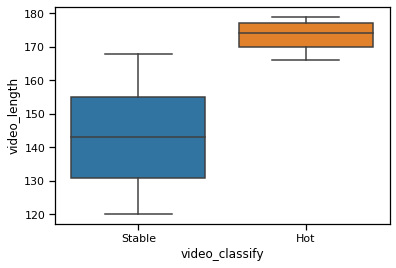

In [102]:
lm1=sns.boxplot(finaldata['video_classify'],finaldata['video_length'])



In [103]:
#sns.boxplot(finaldata['video_classify'],finaldata['counts'])
finaldata.columns

Index(['video_id', 'totalviews', 'popindex', 'video_classify', 'video_quality',
       'video_language', 'video_upload_date', 'video_length'],
      dtype='object')

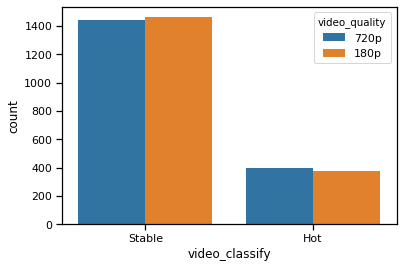

In [104]:
sns.countplot(x="video_classify",hue="video_quality" ,data=finaldata)


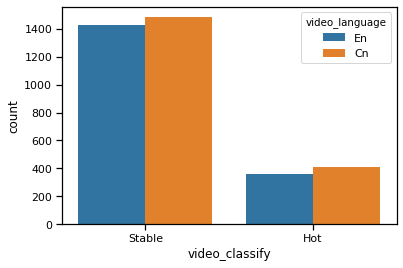

In [105]:
sns.countplot(x="video_classify",hue="video_language" ,data=finaldata)

In [115]:
#Now that we have classified hot videos and stable videos we need to build a recommendation engine using the popularity index defined above

In [116]:
#Pivot the data and generate a sparse matrix to identify similarity between videos usingkneighbors
summarydata_pivot=summarydata.pivot(columns='video_id',values='popindex').fillna(0)

In [117]:
from scipy.sparse import *
from scipy import *

In [118]:
summarydatamatrix=csr_matrix(summarydata_pivot.values)

In [119]:
summarydatamatrix

<3677x3677 sparse matrix of type '<class 'numpy.float64'>'
	with 3677 stored elements in Compressed Sparse Row format>

In [120]:
from sklearn.neighbors import NearestNeighbors

In [121]:
# We will define k neighbors to identify similar videos based on cosine similarities
model_knn=NearestNeighbors(metric='cosine',algorithm='brute')

In [122]:
model_knn.fit(summarydatamatrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [123]:
#Lets showcase a sample recommender for any videoid of our choice
choice=np.random.choice(summarydata_pivot.shape[0])

In [124]:
distances,indices=model_knn.kneighbors(summarydata_pivot.iloc[choice,:].values.reshape(1,-1),n_neighbors=5)

In [125]:
indices

array([[2097, 2452, 2454, 2450, 2453]])

In [126]:
distances

array([[0., 1., 1., 1., 1.]])

In [127]:
distances=distances.flatten()

    

In [129]:
# Here we showcase recommendation for video id 8
for i in range(len(distances)-1):
    print("Recomendation no {0} for video_id {1} is video_id {2}".format(i+1,choice,summarydata_pivot.index[indices.flatten()[i+1]]))

Recomendation no 1 for video_id 2097 is video_id 2452
Recomendation no 2 for video_id 2097 is video_id 2454
Recomendation no 3 for video_id 2097 is video_id 2450
Recomendation no 4 for video_id 2097 is video_id 2453


We have built a simple recommendation engine based on its popularity index as shown above